# Phase 2 — Data Cleaning & EDA

Load normalized tables from PostgreSQL (Phase 1), clean and engineer features, then explore readmission patterns with visualizations.

In [19]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "healthcare",
    "user": "postgres",
    "password": "kanna",  # use same password as Phase 1 (e.g. 'kanna' if you changed it)
}
CONNECTION_URL = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)
engine = create_engine(CONNECTION_URL)
print("Database engine ready.")


Database engine ready.


---
# Part 1 — Data Loading

Connect to PostgreSQL and load normalized tables.

In [20]:
TABLES = ["patients", "admissions", "medications", "lab_results"]
data = {name: pd.read_sql(f"SELECT * FROM {name}", engine) for name in TABLES}
patients = data["patients"]
admissions = data["admissions"]
medications = data["medications"]
lab_results = data["lab_results"]

for name, tbl in data.items():
    print(f"{name:14} {tbl.shape[0]:>8,} rows × {tbl.shape[1]} cols")


patients         71,518 rows × 4 cols
admissions      101,766 rows × 9 cols
medications     119,962 rows × 5 cols
lab_results      22,364 rows × 5 cols


In [21]:
# Merge into one analytical dataset (admission-level grain)
try:
    admission_type_stg = pd.read_sql(
        """
        SELECT DISTINCT admission_id, admission_type_id
        FROM stg_hospital_data
        WHERE admission_type_id IS NOT NULL
        """,
        engine,
    )
except Exception as exc:
    print("admission_type_id not loaded from staging:", exc)
    admission_type_stg = pd.DataFrame(columns=["admission_id", "admission_type_id"])

# Original readmitted labels (NO, <30, >30) live in staging — admissions table only has N/Y
try:
    readmit_stg = pd.read_sql(
        """
        SELECT DISTINCT admission_id, readmitted
        FROM stg_hospital_data
        WHERE readmitted IS NOT NULL
        """,
        engine,
    )
except Exception as exc:
    print("readmitted not loaded from staging:", exc)
    readmit_stg = pd.DataFrame(columns=["admission_id", "readmitted"])

med_agg = (
    medications.groupby("admission_id", as_index=False)
    .agg(
        medication_count=("medication_id", "count"),
        medication_name=("medication_name", lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]),
    )
)
lab_agg = (
    lab_results.groupby("admission_id", as_index=False)
    .agg(lab_test_count=("lab_id", "count"))
)

df = (
    admissions.merge(patients, on="patient_id", how="left", suffixes=("", "_patient"))
    .merge(med_agg, on="admission_id", how="left")
    .merge(lab_agg, on="admission_id", how="left")
)
if not admission_type_stg.empty:
    df = df.merge(admission_type_stg, on="admission_id", how="left")

# Replace N/Y from admissions with NO / <30 / >30 from staging
if not readmit_stg.empty:
    df = df.drop(columns=["readmitted"], errors="ignore")
    df = df.merge(readmit_stg, on="admission_id", how="left")
# Remove duplicate column names from merges
df = df.loc[:, ~df.columns.duplicated(keep="last")]

print("Analytical dataset:", df.shape)
if "readmitted" in df.columns:
    print("readmitted values:\n", df["readmitted"].squeeze().value_counts())
df.head()



Analytical dataset: (101766, 16)
readmitted values:
 readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


,admission_id,patient_id,hospital_id,hospital,admission_date,discharge_date,diagnosis,length_of_stay_days,gender,age,date_of_birth,medication_count,medication_name,lab_test_count,admission_type_id,readmitted
0,12522,48330783,2,?,2015-04-23,2015-05-06,398,13,Female,[80-90),None,2.0,NDC-0049-4110,NaN,2,NO
1,15738,63555939,3,InternalMedicine,2016-02-13,2016-02-25,434,12,Female,[90-100),None,2.0,NDC-0173-0863,NaN,3,NO
2,16680,42519267,2,?,2016-09-12,2016-09-13,197,1,Male,[40-50),None,2.0,NDC-0049-4110,NaN,1,NO
3,28236,89869032,2,?,2016-05-11,2016-05-20,250.7,9,Female,[40-50),None,1.0,NDC-68071-1701,NaN,1,>30
4,35754,82637451,2,?,2016-12-15,2016-12-18,414,3,Male,[50-60),None,1.0,NDC-47918-902,NaN,2,>30


---
# Part 2 — Data Cleaning

Handle missing values, encode categoricals, drop ID columns, and create:

- `readmission_category` — three classes from `readmitted`: **NO**, **<30**, **>30**
- `readmission_flag` — binary target for Phase 3 (**1** = readmitted within 30 days, i.e. **<30** only)

In [22]:
MISSING_MARKERS = {"?", "", "None", "none", "nan", "NaN"}

def clean_missing_markers(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    for col in out.select_dtypes(include=["object", "string"]).columns:
        out[col] = out[col].replace(list(MISSING_MARKERS), np.nan)
    return out

df = clean_missing_markers(df)

# Parse dates
for col in ["admission_date", "discharge_date", "date_of_birth"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   admission_id         101766 non-null  int64         
 1   patient_id           101766 non-null  int64         
 2   hospital_id          101766 non-null  int64         
 3   hospital             51817 non-null   str           
 4   admission_date       101766 non-null  datetime64[us]
 5   discharge_date       101766 non-null  datetime64[us]
 6   diagnosis            101745 non-null  str           
 7   length_of_stay_days  101766 non-null  int64         
 8   gender               101766 non-null  str           
 9   age                  101766 non-null  str           
 10  date_of_birth        0 non-null       datetime64[s] 
 11  medication_count     78304 non-null   float64       
 12  medication_name      78304 non-null   str           
 13  lab_test_count       2206

In [23]:
# 1. Handle missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]

# Numeric: median imputation (robust for skewed healthcare counts)
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical: mode imputation
for col in categorical_cols:
    if col == "readmitted":
        continue
    if df[col].isna().any():
        mode_val = df[col].mode(dropna=True)
        if len(mode_val):
            df[col] = df[col].fillna(mode_val.iloc[0])

# Dates: drop rows missing admission_date; infer discharge_date from length_of_stay if available
if "admission_date" in df.columns:
    before = len(df)
    df = df.dropna(subset=["admission_date"])
    print(f"Dropped {before - len(df):,} rows with missing admission_date")
if "discharge_date" in df.columns and "length_of_stay_days" in df.columns:
    mask = df["discharge_date"].isna() & df["length_of_stay_days"].notna()
    df.loc[mask, "discharge_date"] = df.loc[mask, "admission_date"] + pd.to_timedelta(
        df.loc[mask, "length_of_stay_days"], unit="D"
    )
elif "discharge_date" in df.columns and "length_of_stay" in df.columns:
    mask = df["discharge_date"].isna() & df["length_of_stay"].notna()
    df.loc[mask, "discharge_date"] = df.loc[mask, "admission_date"] + pd.to_timedelta(
        df.loc[mask, "length_of_stay"], unit="D"
    )

print("Missing values after imputation:", int(df.isna().sum().sum()))


Dropped 0 rows with missing admission_date
Missing values after imputation: 101766


In [24]:
# 2. Three-category readmission + binary 30-day target (Phase 3)
READMISSION_CATEGORIES = ["NO", "<30", ">30"]


def normalize_readmitted(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()
    mapping = {
        "NO": "NO", "N": "NO",
        "<30": "<30", "LT30": "<30",
        ">30": ">30", "GT30": ">30",
    }
    return mapping.get(s, np.nan)


def get_series(frame: pd.DataFrame, col: str) -> pd.Series:
    """Return one Series even if duplicate column labels exist."""
    data = frame[col]
    if isinstance(data, pd.DataFrame):
        data = data.iloc[:, 0]
    return data.squeeze()


# Drop duplicate columns before creating targets
df = df.loc[:, ~df.columns.duplicated(keep="last")]

# Remove prior target columns if re-running this cell
for col in ["readmission_flag", "readmission_category"]:
    if col in df.columns:
        df = df.drop(columns=[col])

if "readmitted" in df.columns:
    readmitted = get_series(df, "readmitted").apply(normalize_readmitted)
    df["readmitted"] = readmitted
    df = df[df["readmitted"].isin(READMISSION_CATEGORIES)].copy()
    df["readmission_category"] = pd.Categorical(
        df["readmitted"],
        categories=READMISSION_CATEGORIES,
        ordered=True,
    )
    df["readmission_flag"] = (df["readmission_category"] == "<30").astype(int)
elif "readmitted_yn" in df.columns:
    df["readmission_category"] = get_series(df, "readmitted_yn").apply(
        lambda x: "NO" if str(x).strip().upper() in ("N", "NO") else ">30"
    )
    df["readmission_category"] = pd.Categorical(
        df["readmission_category"],
        categories=READMISSION_CATEGORIES,
        ordered=True,
    )
    df["readmission_flag"] = (df["readmission_category"] == "<30").astype(int)
else:
    raise ValueError("Neither 'readmitted' nor 'readmitted_yn' found in df.")

df = df.loc[:, ~df.columns.duplicated(keep="last")]

print("readmission_category (3 classes):")
print(df["readmission_category"].value_counts().sort_index())
print("\nreadmission_flag — 30-day readmission (<30 only):")
print(df["readmission_flag"].value_counts())
print(f"\n30-day readmission rate: {100 * df['readmission_flag'].mean():.2f}%")



readmission_category (3 classes):
readmission_category
NO     54864
<30    11357
>30    35545
Name: count, dtype: int64

readmission_flag — 30-day readmission (<30 only):
readmission_flag
0    90409
1    11357
Name: count, dtype: int64

30-day readmission rate: 11.16%


In [25]:
# 3. Encode categorical variables
label_encode_cols = [c for c in ["gender", "diagnosis"] if c in df.columns]
label_encoders = {}
for col in label_encode_cols:
    le = LabelEncoder()
    df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# One-hot encode categoricals (build list after derived columns exist)
one_hot_cols = []
if "medication_name" in df.columns:
    top_med = df["medication_name"].value_counts().head(15).index
    df["medication_name_top"] = df["medication_name"].where(
        df["medication_name"].isin(top_med), "Other"
    )
    one_hot_cols.append("medication_name_top")
if "admission_type_id" in df.columns:
    one_hot_cols.append("admission_type_id")

one_hot_cols = [c for c in one_hot_cols if c in df.columns]

if one_hot_cols:
    ohe_parts = [
        pd.get_dummies(df[[col]], prefix=col, drop_first=True) for col in one_hot_cols
    ]

    df = pd.concat([df] + ohe_parts, axis=1)

# Remove duplicate columns after one-hot concat
df = df.loc[:, ~df.columns.duplicated(keep="last")]

print("Encoded columns added:", [c for c in df.columns if c.endswith("_encoded") or "_top_" in c][:8], "...")



Encoded columns added: ['gender_encoded', 'diagnosis_encoded', 'medication_name_top_NDC-0049-4110', 'medication_name_top_NDC-0049-4120', 'medication_name_top_NDC-0093-9477', 'medication_name_top_NDC-0115-1743', 'medication_name_top_NDC-0173-0861', 'medication_name_top_NDC-0173-0863'] ...


In [26]:
# 4. Remove irrelevant / duplicate columns for modeling frame
drop_cols = [
    "patient_id", "admission_id", "medication_id", "lab_id",
    "readmitted", "readmitted_yn", "date_of_birth",
]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.loc[:, ~df.columns.duplicated(keep="last")]
df_model = df.drop(columns=drop_cols, errors="ignore")
df_model = df_model.loc[:, ~df_model.columns.duplicated()]
print("Modeling frame shape:", df_model.shape)
df_model.head()


Modeling frame shape: (101766, 32)


,hospital_id,hospital,admission_date,discharge_date,diagnosis,length_of_stay_days,gender,age,medication_count,medication_name,...,medication_name_top_NDC-0378-0228,medication_name_top_NDC-0378-1110,medication_name_top_NDC-0591-0461,medication_name_top_NDC-0781-5420,medication_name_top_NDC-47918-898,medication_name_top_NDC-47918-902,medication_name_top_NDC-50090-0353,medication_name_top_NDC-68071-1701,medication_name_top_Other,admission_type_id
0,2,InternalMedicine,2015-04-23,2015-05-06,398,13,Female,[80-90),2.0,NDC-0049-4110,...,False,False,False,False,False,False,False,False,False,2
1,3,InternalMedicine,2016-02-13,2016-02-25,434,12,Female,[90-100),2.0,NDC-0173-0863,...,False,False,False,False,False,False,False,False,False,3
2,2,InternalMedicine,2016-09-12,2016-09-13,197,1,Male,[40-50),2.0,NDC-0049-4110,...,False,False,False,False,False,False,False,False,False,1
3,2,InternalMedicine,2016-05-11,2016-05-20,250.7,9,Female,[40-50),1.0,NDC-68071-1701,...,False,False,False,False,False,False,False,True,False,1
4,2,InternalMedicine,2016-12-15,2016-12-18,414,3,Male,[50-60),1.0,NDC-47918-902,...,False,False,False,False,False,True,False,False,False,2


---
# Part 3 — Feature Engineering

Create length of stay and per-admission counts (age_group excluded — raw age brackets retained in `patients` only).

In [27]:
if "discharge_date" in df.columns and "admission_date" in df.columns:
    df["length_of_stay"] = (df["discharge_date"] - df["admission_date"]).dt.days
elif "length_of_stay_days" in df.columns:
    df["length_of_stay"] = df["length_of_stay_days"]
df_model["length_of_stay"] = df["length_of_stay"]

df["medication_count"] = df.get("medication_count", pd.Series(0, index=df.index)).fillna(0)
df["lab_test_count"] = df.get("lab_test_count", pd.Series(0, index=df.index)).fillna(0)
df_model["medication_count"] = df["medication_count"]
df_model["lab_test_count"] = df["lab_test_count"]

df[[ "length_of_stay", "medication_count", "lab_test_count", "readmission_flag"]].describe(include="all")


,length_of_stay,medication_count,lab_test_count,readmission_flag
count,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,1.409351,1.002928,0.111599
std,2.985108,0.693572,0.054035,0.314874
min,1.000000,1.000000,1.000000,0.000000
25%,2.000000,1.000000,1.000000,0.000000
50%,4.000000,1.000000,1.000000,0.000000
75%,6.000000,2.000000,1.000000,0.000000
max,14.000000,6.000000,2.000000,1.000000


---
# Part 4 — Exploratory Data Analysis (EDA)

Visualize readmission drivers and distributions.

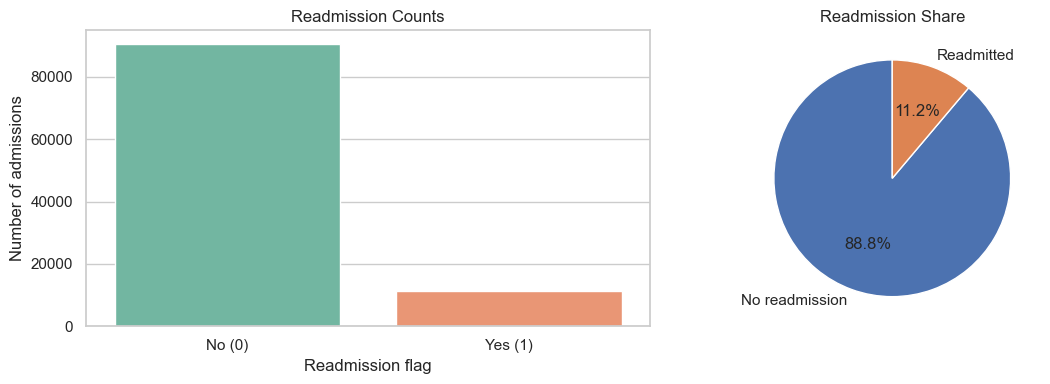

In [28]:
# 1. Readmission distribution
df = df.loc[:, ~df.columns.duplicated(keep="last")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["readmission_flag"].value_counts().sort_index()
sns.barplot(x=counts.index.map({0: "No (0)", 1: "Yes (1)"}), y=counts.values, ax=axes[0], palette="Set2")
axes[0].set_title("Readmission Counts")
axes[0].set_xlabel("Readmission flag")
axes[0].set_ylabel("Number of admissions")
axes[1].pie(counts.values, labels=["No readmission", "Readmitted"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Readmission Share")
plt.tight_layout()
plt.show()


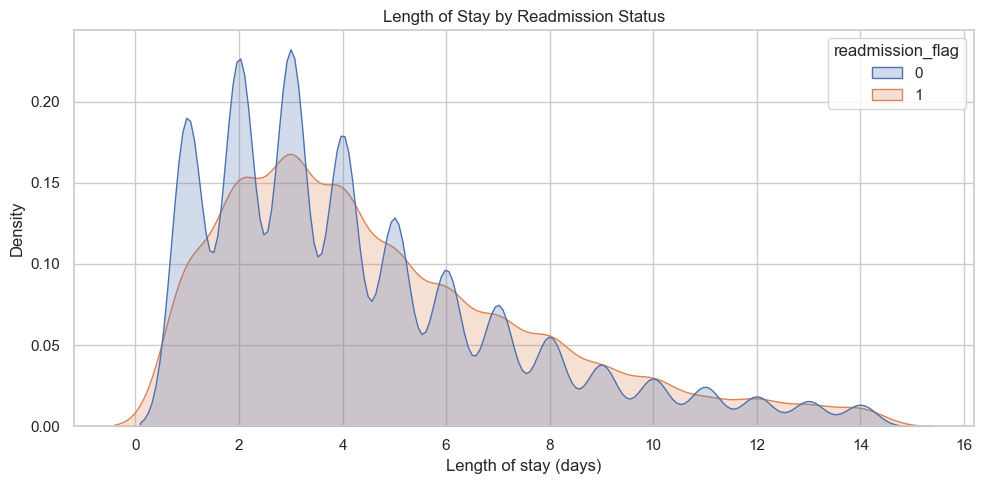

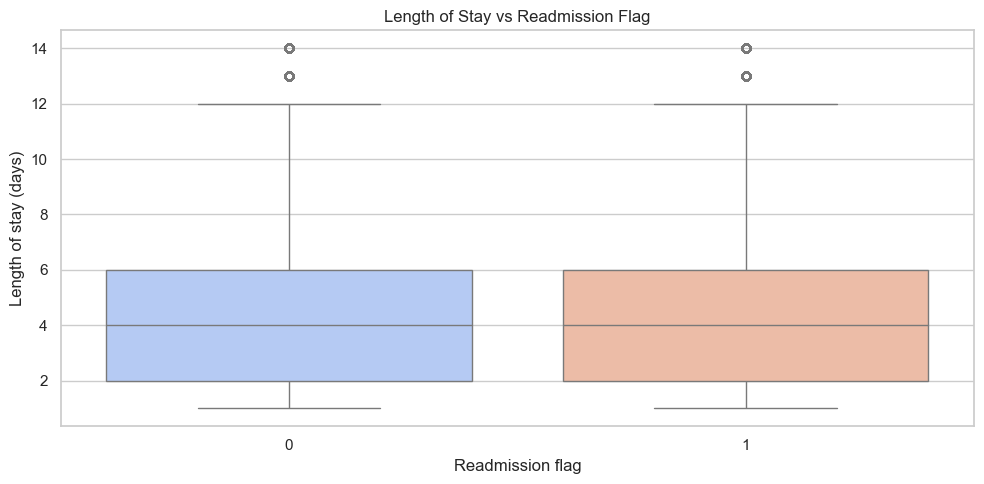

In [29]:
# 2. Length of stay vs readmission
los = df["length_of_stay"].dropna()
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="length_of_stay", hue="readmission_flag", fill=True, common_norm=False)
plt.title("Length of Stay by Readmission Status")
plt.xlabel("Length of stay (days)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="readmission_flag", y="length_of_stay", palette="coolwarm")
plt.title("Length of Stay vs Readmission Flag")
plt.xlabel("Readmission flag")
plt.ylabel("Length of stay (days)")
plt.tight_layout()
plt.show()


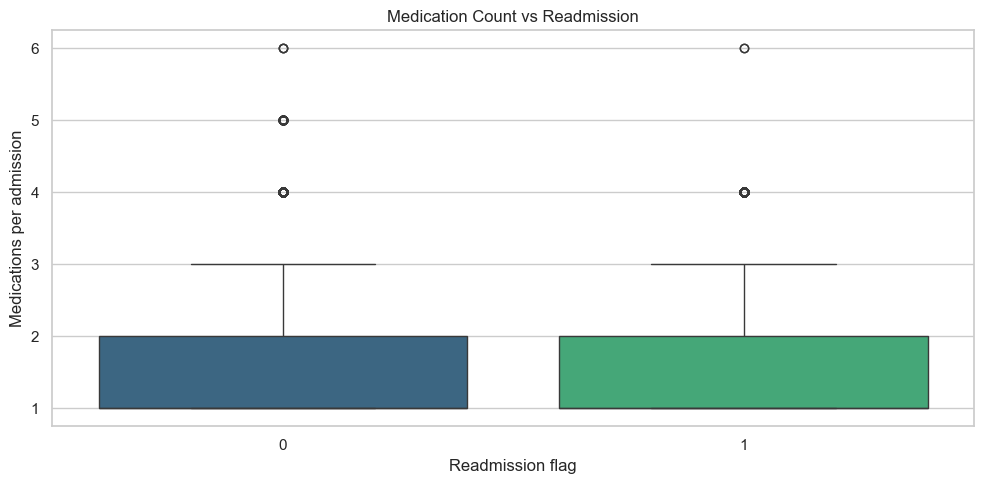

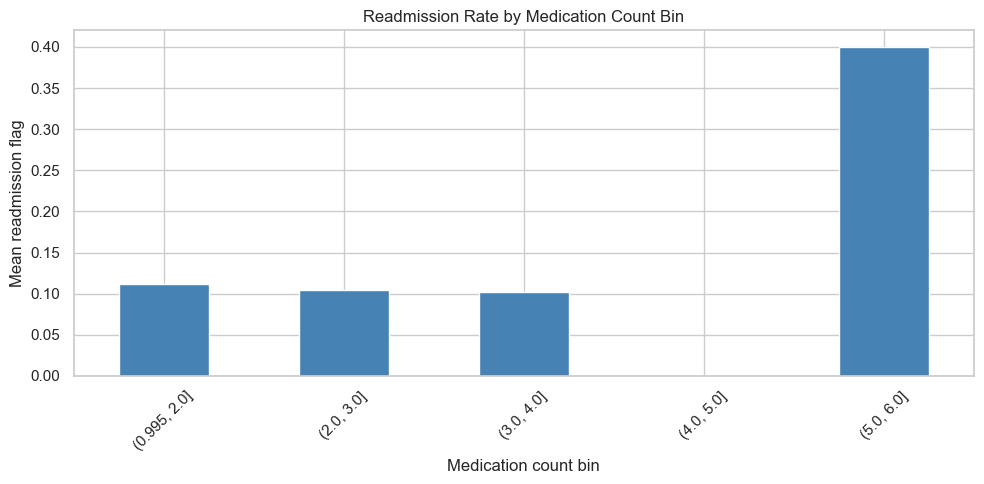

In [30]:
# 3. Medication count vs readmission
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="readmission_flag", y="medication_count", palette="viridis")
plt.title("Medication Count vs Readmission")
plt.xlabel("Readmission flag")
plt.ylabel("Medications per admission")
plt.tight_layout()
plt.show()

rate_med = df.groupby(pd.cut(df["medication_count"], bins=5))["readmission_flag"].mean()
plt.figure(figsize=(10, 5))
rate_med.plot(kind="bar", color="steelblue")
plt.title("Readmission Rate by Medication Count Bin")
plt.xlabel("Medication count bin")
plt.ylabel("Mean readmission flag")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


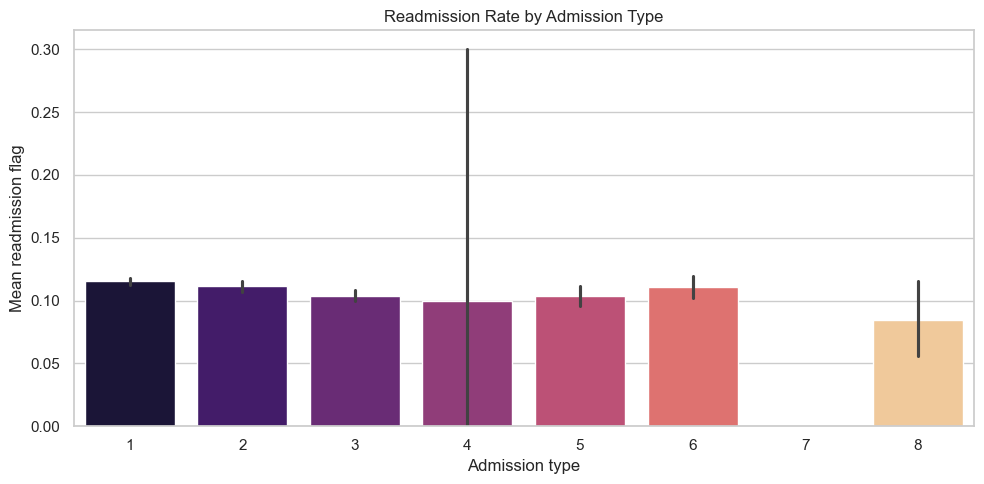

In [31]:
# 4. Admission type vs readmission
df = df.loc[:, ~df.columns.duplicated(keep="last")]

if "readmission_flag" in df.columns and isinstance(df["readmission_flag"], pd.DataFrame):
    df["readmission_flag"] = df["readmission_flag"].iloc[:, 0]

if "admission_type_id" in df.columns:
    type_col = "admission_type_id"
elif "admission_type" in df.columns:
    type_col = "admission_type"
else:
    type_col = None

if type_col:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x=type_col, y="readmission_flag", estimator="mean", errorbar="ci", palette="magma")
    plt.title("Readmission Rate by Admission Type")
    plt.xlabel("Admission type")
    plt.ylabel("Mean readmission flag")
    plt.tight_layout()
    plt.show()
else:
    print("admission_type_id not available — using hospital/service line as proxy.")
    if "hospital" in df.columns:
        top_h = df["hospital"].value_counts().head(10).index
        subset = df[df["hospital"].isin(top_h)]
        plt.figure(figsize=(12, 5))
        sns.barplot(data=subset, x="hospital", y="readmission_flag", estimator="mean", palette="magma")
        plt.title("Readmission Rate by Hospital / Service Line (Top 10)")
        plt.xlabel("Hospital / service line")
        plt.ylabel("Mean readmission flag")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()



---
# Part 5 — Summary Insights

Key observations from cleaning and EDA:

In [32]:
readmit_rate = 100 * df["readmission_flag"].mean()
print(f"Overall readmission rate: {readmit_rate:.2f}%")
if "length_of_stay" in df.columns:
    print("\nMedian length of stay (readmitted=1):", df.loc[df["readmission_flag"] == 1, "length_of_stay"].median())
    print("Median length of stay (readmitted=0):", df.loc[df["readmission_flag"] == 0, "length_of_stay"].median())
print("\nMedian medication count by readmission flag:")
print(df.groupby("readmission_flag")["medication_count"].median())
print("\nCleaned modeling dataset saved in memory as `df_model` for Phase 3 (ML).")


Overall readmission rate: 11.16%

Median length of stay (readmitted=1): 4.0
Median length of stay (readmitted=0): 4.0

Median medication count by readmission flag:
readmission_flag
0    1.0
1    1.0
Name: medication_count, dtype: float64

Cleaned modeling dataset saved in memory as `df_model` for Phase 3 (ML).
